In [2]:
import os

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings

sns.set_theme()
warnings.filterwarnings('ignore')

In [3]:
problems = ["chemical_1_tower", "chemical_2_competition", "friction_dyn_one-hot", "friction_stat_one-hot",
            "nasa_battery_1_10min", "nasa_battery_2_20min", "nikuradse_1", "nikuradse_2", "flow_stress_phip0.1", ]

In [4]:
dfs = []
for problem in problems:
    for seed in range(10):
        if os.path.exists(f"../results/GP_{problem}_{seed}.pickle"):
            tmp_df = pd.read_csv(f"../results/GP_{problem}_{seed}.csv")
            tmp_df["run"] = seed
            tmp_df["algorithm"] = "JaxGP"
            tmp_df["dataset"] = problem
            tmp_df["total_time"] = tmp_df["time"].cumsum().astype(int)
            dfs.append(tmp_df)
        else:
            pass
df = pd.concat(dfs, ignore_index=True)
df["r2_test"] = df["test_accuracy"].str.replace(r"[\[\]]", "", regex=True).astype(float)
df.head()

,iteration,max_fitness,time,test_accuracy,run,algorithm,dataset,total_time,r2_test
0,0,-0.943658,0.000000,-1.0098057,0,JaxGP,chemical_1_tower,0,-1.009806
1,1,-0.694493,20.506563,[-0.988152],0,JaxGP,chemical_1_tower,20,-0.988152
2,2,0.282013,9.692096,[0.28767782],0,JaxGP,chemical_1_tower,30,0.287678
3,3,0.283639,9.687017,[0.28767782],0,JaxGP,chemical_1_tower,39,0.287678
4,4,0.296829,9.840817,[0.35737818],0,JaxGP,chemical_1_tower,49,0.357378


In [5]:
baselines = pd.read_csv("baselines.csv")[["run", "algorithm", "dataset", "r2_test"]]
baselines = baselines[baselines["dataset"].isin(problems)]
baseline_algos = ["Operon", "QLattice", "PySR", "eggp"]
baselines = baselines[baselines["algorithm"].isin(baseline_algos)]
baselines.head()

,run,algorithm,dataset,r2_test
4696,0,eggp,chemical_1_tower,0.876939
4697,1,eggp,chemical_1_tower,0.857567
4698,2,eggp,chemical_1_tower,0.868668
4699,3,eggp,chemical_1_tower,0.829023
4700,4,eggp,chemical_1_tower,0.840139


In [6]:
cgp_df = pd.read_csv("cgp.csv")
cgp_df = cgp_df[cgp_df["iteration"] == max(cgp_df["iteration"])].reset_index(drop=True)[["run", "algorithm", "dataset", "r2_test"]]
cgp_df.head

<bound method NDFrame.head of      run algorithm              dataset   r2_test
0      0       CGP     chemical_1_tower  0.607127
1      1       CGP     chemical_1_tower  0.595511
2      2       CGP     chemical_1_tower  0.535032
3      3       CGP     chemical_1_tower  0.583234
4      4       CGP     chemical_1_tower  0.599222
..   ...       ...                  ...       ...
265   25       CGP  flow_stress_phip0.1  0.880080
266   26       CGP  flow_stress_phip0.1  0.948680
267   27       CGP  flow_stress_phip0.1  0.964351
268   28       CGP  flow_stress_phip0.1  0.987378
269   29       CGP  flow_stress_phip0.1  0.924524

[270 rows x 4 columns]>

In [7]:
final_df = df[df["iteration"] == max(df["iteration"])].reset_index(drop=True)[["run", "algorithm", "dataset", "r2_test"]]
final_df.head()

,run,algorithm,dataset,r2_test
0,0,JaxGP,chemical_1_tower,0.492187
1,1,JaxGP,chemical_1_tower,0.519054
2,2,JaxGP,chemical_1_tower,0.496462
3,3,JaxGP,chemical_1_tower,0.592214
4,4,JaxGP,chemical_1_tower,0.453226


In [8]:
merge_df = pd.concat([final_df, baselines, cgp_df], ignore_index=True)
merge_df.head()

,run,algorithm,dataset,r2_test
0,0,JaxGP,chemical_1_tower,0.492187
1,1,JaxGP,chemical_1_tower,0.519054
2,2,JaxGP,chemical_1_tower,0.496462
3,3,JaxGP,chemical_1_tower,0.592214
4,4,JaxGP,chemical_1_tower,0.453226


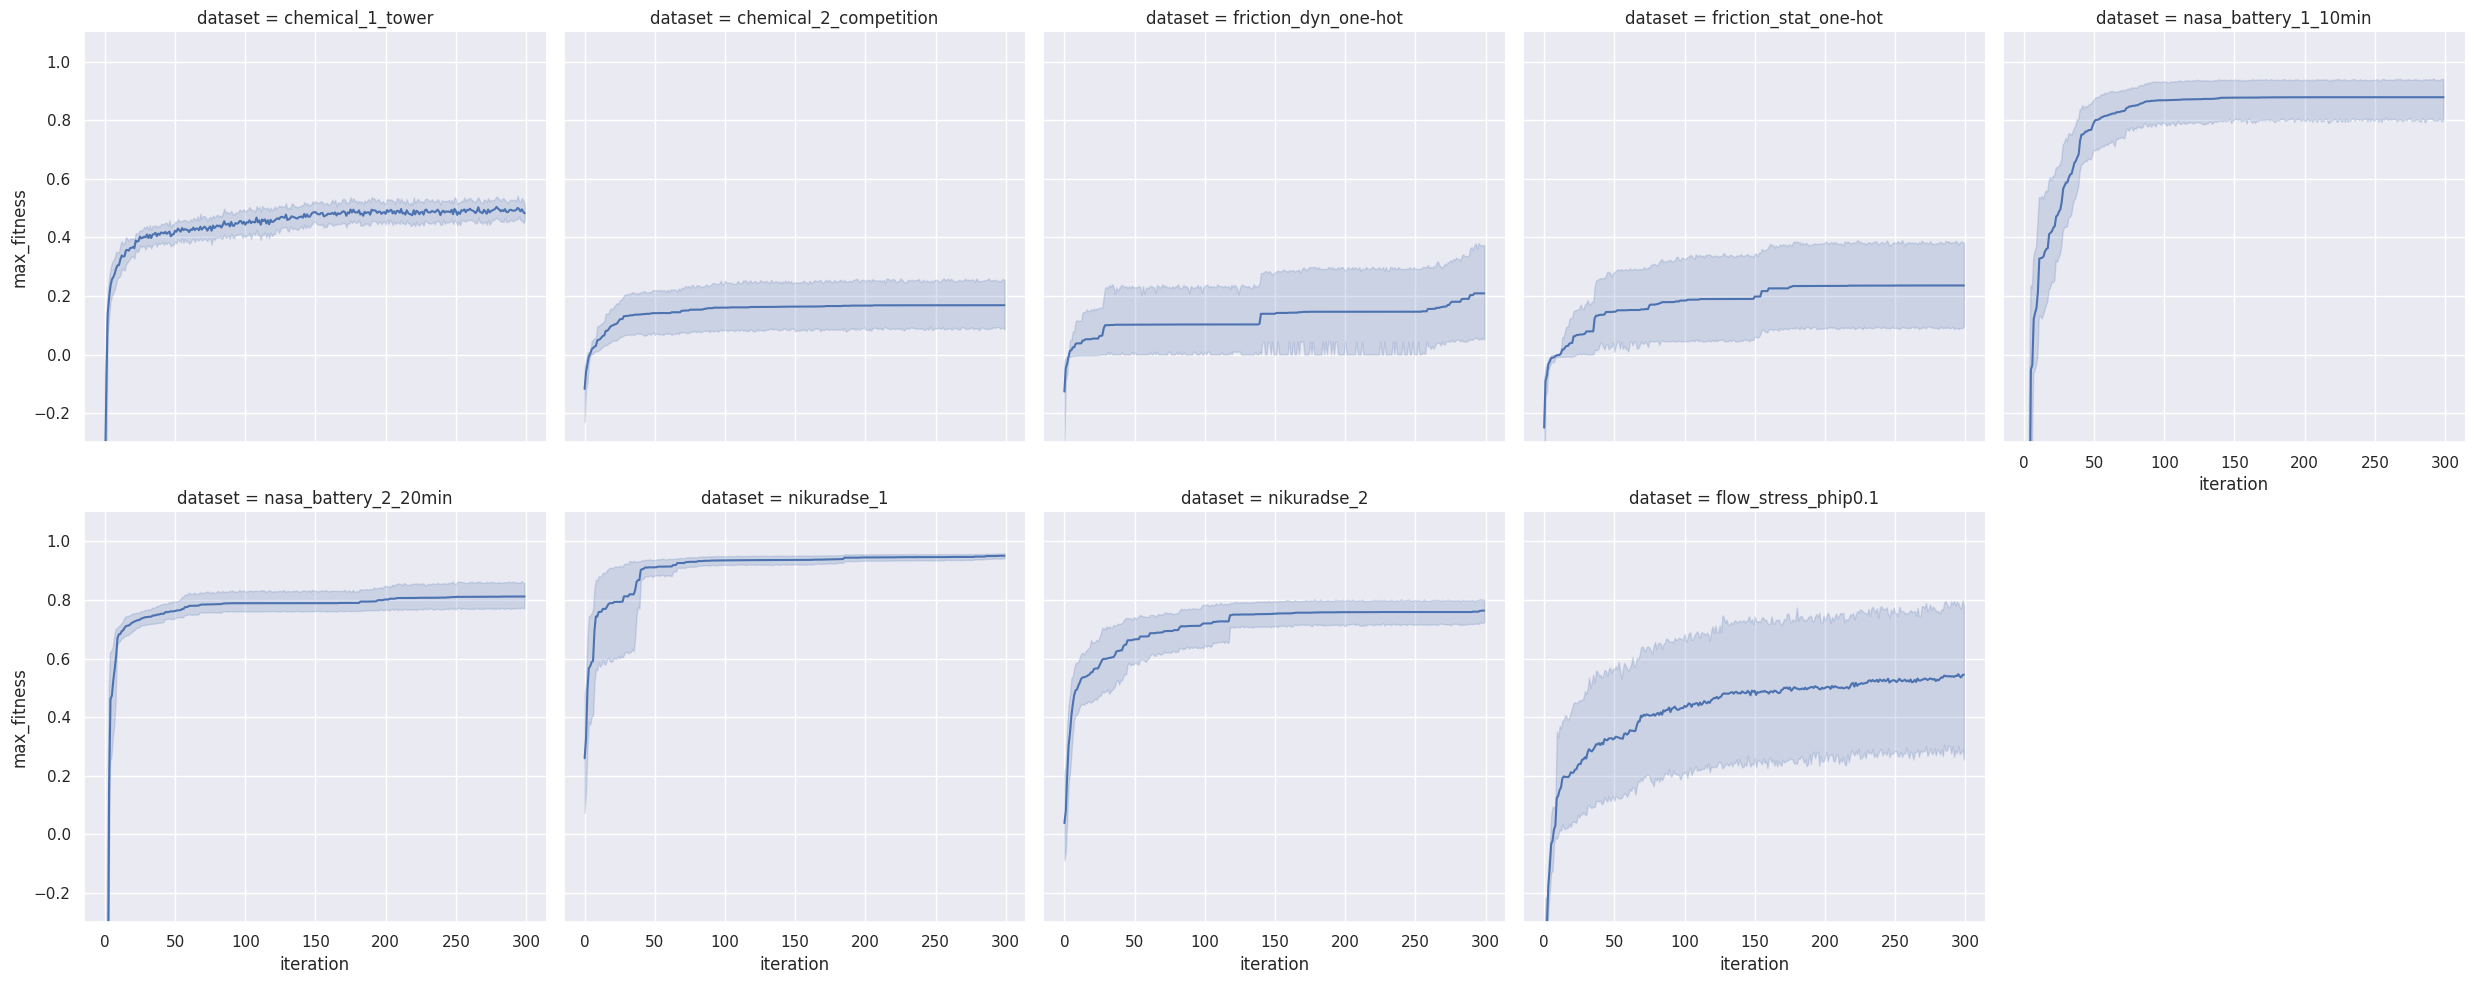

In [9]:
sns.relplot(df, x="iteration", y="max_fitness", col="dataset", col_wrap=5, kind="line")
plt.ylim(-.3, 1.1)
plt.show()

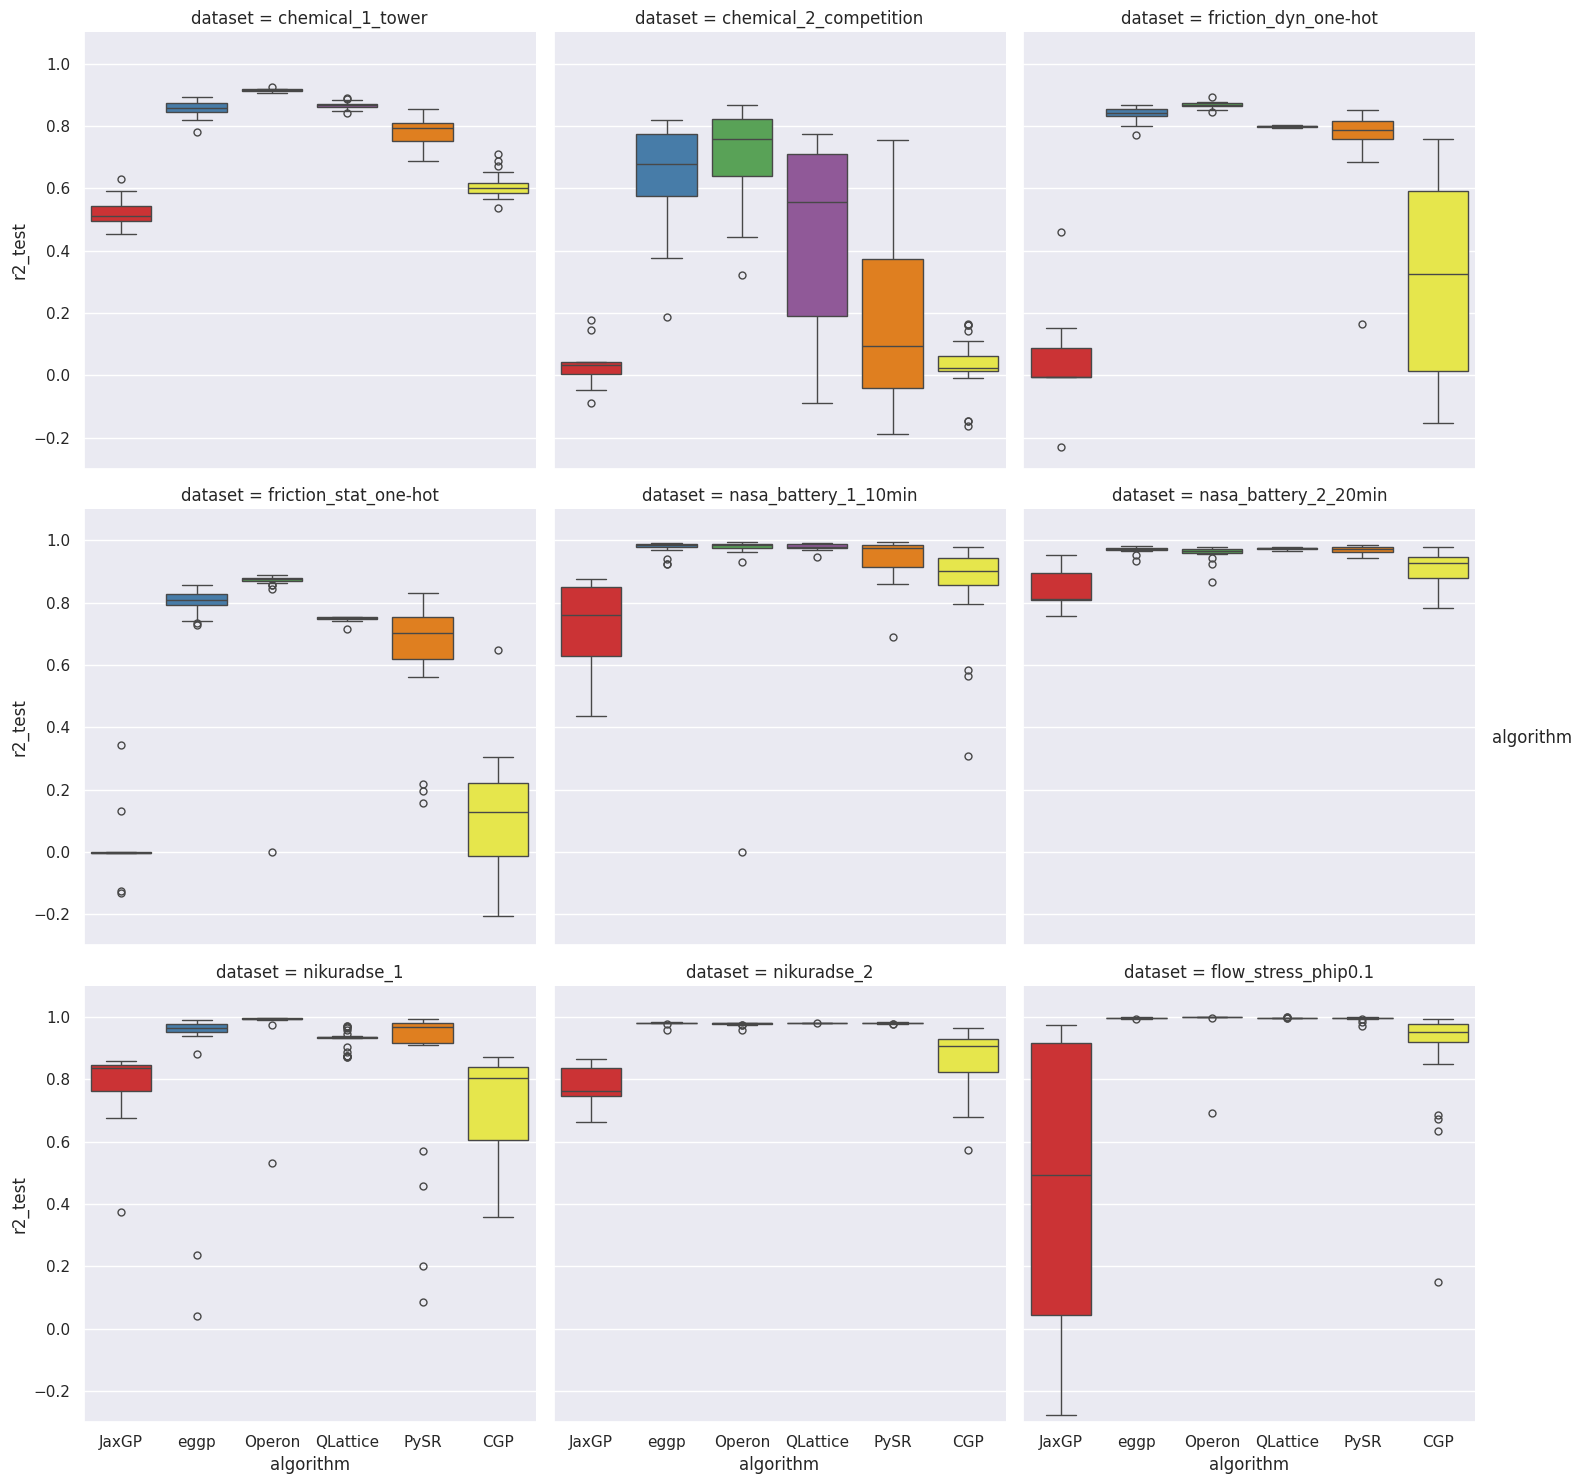

In [11]:
sns.catplot(x="algorithm", y="r2_test", hue="algorithm", data=merge_df, col_wrap=3,  # row="when",
            col="dataset", kind="box", palette="Set1")
plt.ylim(-.3, 1.1)
plt.show()